# 🧠 Case Study : Predict Customer Cancellation

 [Case Study Link](https://docs.google.com/document/d/1DrkN30mmBapBX146OvhscGHtAnjqkWkO7scGCNnLqvc/edit#heading=h.wpciijalbsdh)

<div class="alert alert-block alert-success">
      
 👨‍🏫 **Vikesh K**      
  

</div>

<div class="alert alert-block alert-danger">
    
# OH Agenda 📝
    
We will cover:

* Cancellation Prediction
    * EDA with respect to model building
    * Data Prep
    * Model Building
        * Logistic Regression
        * Decision Tree
        * DT Feature importance
        * DT Tree Visualise

        
 </div>

##  <font color= darkred> Import modules and data </font>

In [1]:
# data manipulation
import pandas as pd
import numpy as np

# data viz
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight") # styling the charts

import warnings
warnings.filterwarnings('ignore')
plt.rcParams["image.cmap"] = 'Blues'

**Load Data**

In [2]:
url = 'https://raw.githubusercontent.com/vkoul/data/main/misc/hotel_bookings.csv'

df = pd.read_csv(url)

##  <font color= darkred> Data Inspection</font>🔍📊

### <font color= darkred> Numerical inspection and summaries </font>

**Data Inspect**

In [3]:
df.sample(6)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
19173,3,0,1,1,Meal Plan 1,0,Room_Type 1,33,2018,1,25,Corporate,0,0,0,95.00,1,Not_Canceled
37062,2,0,2,2,Not Selected,0,Room_Type 1,72,2019,6,30,Online,0,0,0,120.00,2,Not_Canceled
51242,2,0,2,4,Meal Plan 1,0,Room_Type 1,222,2018,8,28,Online,0,0,0,100.58,1,Canceled
40235,1,0,0,1,Meal Plan 1,0,Room_Type 1,14,2019,2,21,Corporate,0,0,0,80.00,0,Not_Canceled
15670,2,0,2,1,Meal Plan 1,0,Room_Type 1,55,2018,4,3,Offline,0,0,0,75.00,1,Not_Canceled
30907,2,0,0,3,Not Selected,0,Room_Type 1,1,2019,1,26,Online,0,0,0,88.00,3,Not_Canceled


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56926 entries, 0 to 56925
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          56926 non-null  int64  
 1   no_of_children                        56926 non-null  int64  
 2   no_of_weekend_nights                  56926 non-null  int64  
 3   no_of_week_nights                     56926 non-null  int64  
 4   type_of_meal_plan                     56926 non-null  str    
 5   required_car_parking_space            56926 non-null  int64  
 6   room_type_reserved                    56926 non-null  str    
 7   lead_time                             56926 non-null  int64  
 8   arrival_year                          56926 non-null  int64  
 9   arrival_month                         56926 non-null  int64  
 10  arrival_date                          56926 non-null  int64  
 11  market_segment_type       

### Learner Hypothesis

**Data Quality**

* Should have right data type
* Missing values
* no duplicates
* Check for outliers

**EDA** \ **Business Hypothesis**

Univariate Analyis
* Cancelattion

Bivariate Analysis Cancellation and :
* Lead time
* Number of travellors
* Repeat Customer
* Correlations- for numeric
* Ratio for Categorical

**Pre-processing for ML**
* Train-Test Split
* Standard Scaler
* One-Hot Encoding
* Imputation

**Tuning**
* Hyperparameter
* max_depth
* min_sample_leaf_size

**Evaluation**
* accuracy
* DummyClassifier
* Precision/ Recall/
* Cost of FP and FN
* Confusion Matrix


**Adding the components of date**

In [5]:
# NOTE: pandas removed the `parse_dates={col: [list of cols]}` syntax.
# Build the arrival date from the three separate columns instead.
df = pd.read_csv(url)

# Some rows contain an invalid calendar date (e.g. 29 Feb 2018 - not a leap year).
# Build the date with errors='coerce' so invalid dates become NaT, then drop them.
df["complete_arrival_date"] = pd.to_datetime(
    dict(year=df["arrival_year"], month=df["arrival_month"], day=df["arrival_date"]),
    errors="coerce",
)

# drop the original split date columns (recreated below from the datetime)
df = df.drop(columns=["arrival_year", "arrival_month", "arrival_date"])

In [6]:
df.head(2)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,complete_arrival_date
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,65.00,0,Not_Canceled,2017-10-02
1,2,0,2,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled,2018-11-06


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56926 entries, 0 to 56925
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          56926 non-null  int64         
 1   no_of_children                        56926 non-null  int64         
 2   no_of_weekend_nights                  56926 non-null  int64         
 3   no_of_week_nights                     56926 non-null  int64         
 4   type_of_meal_plan                     56926 non-null  str           
 5   required_car_parking_space            56926 non-null  int64         
 6   room_type_reserved                    56926 non-null  str           
 7   lead_time                             56926 non-null  int64         
 8   market_segment_type                   56926 non-null  str           
 9   repeated_guest                        56926 non-null  int64         
 10  no_of_pre

In [8]:
# pd.to_datetime(df['complete_arrival_date'])

In [9]:
# df.iloc[4108,]

In [10]:
# Invalid dates were coerced to NaT above; drop them here
df = df.dropna(subset=["complete_arrival_date"]).copy()

In [11]:
df["complete_arrival_date"] = pd.to_datetime(df["complete_arrival_date"]).copy()

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 56889 entries, 0 to 56925
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          56889 non-null  int64         
 1   no_of_children                        56889 non-null  int64         
 2   no_of_weekend_nights                  56889 non-null  int64         
 3   no_of_week_nights                     56889 non-null  int64         
 4   type_of_meal_plan                     56889 non-null  str           
 5   required_car_parking_space            56889 non-null  int64         
 6   room_type_reserved                    56889 non-null  str           
 7   lead_time                             56889 non-null  int64         
 8   market_segment_type                   56889 non-null  str           
 9   repeated_guest                        56889 non-null  int64         
 10  no_of_previous

In [13]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,complete_arrival_date
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,65.00,0,Not_Canceled,2017-10-02
1,2,0,2,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled,2018-11-06
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,60.00,0,Canceled,2018-02-28
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,0,Canceled,2018-05-20
4,3,0,0,3,Not Selected,0,Room_Type 1,277,Online,0,0,0,89.10,2,Canceled,2019-07-13


##   <font color= darkred> Data Quality Check </font>

**Missing values check**

In [14]:
df.isna().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
complete_arrival_date                   0
dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 56889 entries, 0 to 56925
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          56889 non-null  int64         
 1   no_of_children                        56889 non-null  int64         
 2   no_of_weekend_nights                  56889 non-null  int64         
 3   no_of_week_nights                     56889 non-null  int64         
 4   type_of_meal_plan                     56889 non-null  str           
 5   required_car_parking_space            56889 non-null  int64         
 6   room_type_reserved                    56889 non-null  str           
 7   lead_time                             56889 non-null  int64         
 8   market_segment_type                   56889 non-null  str           
 9   repeated_guest                        56889 non-null  int64         
 10  no_of_previous

In [16]:
df.duplicated().sum()

np.int64(14348)

In [17]:
df.shape

(56889, 16)

In [18]:
df = df.drop_duplicates()

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['booking_status'].value_counts(normalize = True).round(2)

booking_status
Not_Canceled    0.66
Canceled        0.34
Name: proportion, dtype: float64

**Cleaning the booking_status column**

In [21]:
# Cast to int: in recent pandas, replace() on a string column returns object dtype,
# which scikit-learn rejects as "unknown label type". astype(int) makes them proper classes.
df['booking_status'] = df['booking_status'].replace({'Not_Canceled': 0,  'Canceled': 1}).astype(int)

In [22]:
df['booking_status'].value_counts(normalize = True).round(2)

booking_status
0    0.66
1    0.34
Name: proportion, dtype: float64

In [23]:
df['booking_status'].mean()

np.float64(0.34037751815895256)

**Extracting the relevant values from the date column**

In [24]:
df['year'] = df['complete_arrival_date'].dt.year

df['month'] = df['complete_arrival_date'].dt.month

df['month_name'] = df['complete_arrival_date'].dt.month_name()

df['day'] = df['complete_arrival_date'].dt.day

df['day_name'] = df['complete_arrival_date'].dt.day_name()

In [25]:
df[["year", "month", "month_name", "day", "day_name", "complete_arrival_date"]].head()

,year,month,month_name,day,day_name,complete_arrival_date
0,2017,10,October,2,Monday,2017-10-02
1,2018,11,November,6,Tuesday,2018-11-06
2,2018,2,February,28,Wednesday,2018-02-28
3,2018,5,May,20,Sunday,2018-05-20
4,2019,7,July,13,Saturday,2019-07-13


##   <font color= darkred> EDA </font>

### Univariate Analysis

year
2017    0.122271
2018    0.315286
2019    0.425012
Name: booking_status, dtype: float64

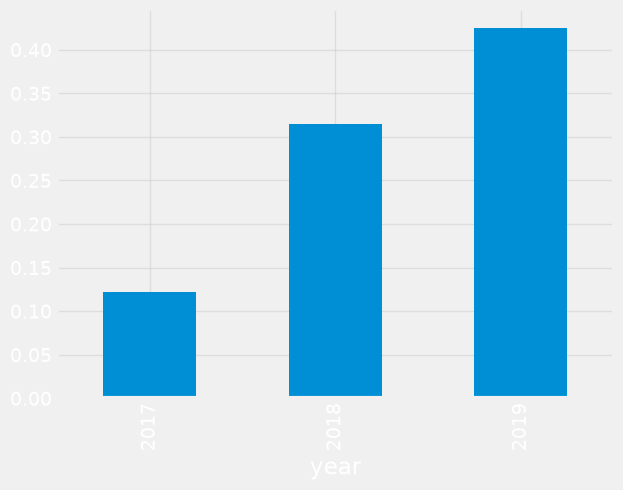

In [26]:
display(df.groupby('year')['booking_status'].mean())

df.groupby('year')['booking_status'].mean().plot(kind = 'bar');

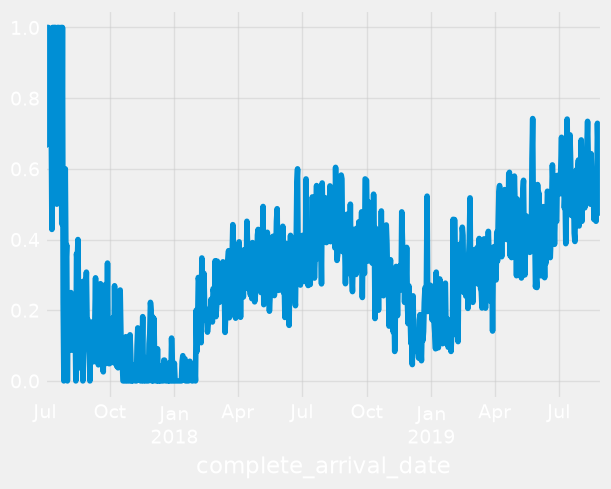

In [27]:
df.groupby(['complete_arrival_date'])['booking_status'].mean().plot(kind = 'line');

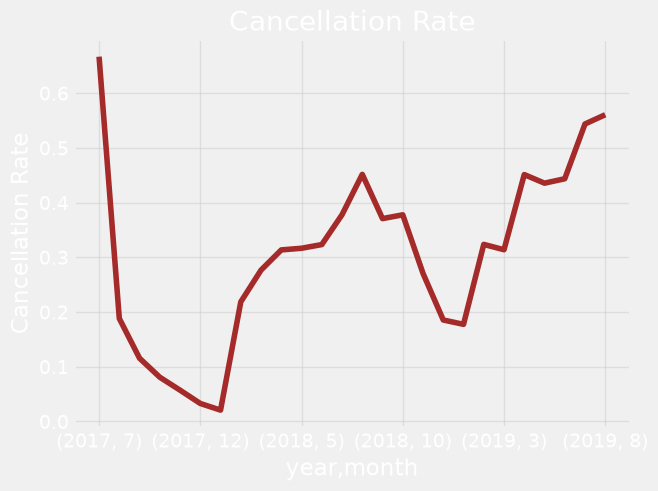

In [28]:
df.groupby(['year' ,'month'])['booking_status'].mean().plot(kind = 'line', color = "brown", title = "Cancellation Rate", ylabel = "Cancellation Rate");

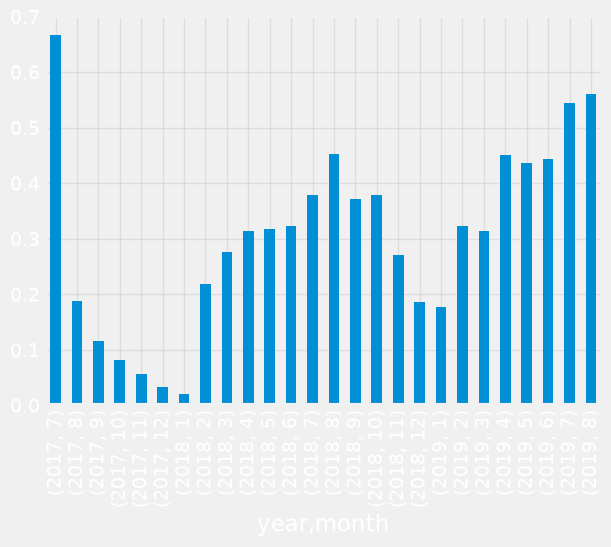

In [29]:
df.groupby(['year' ,'month'])['booking_status'].mean().plot(kind = 'bar');

In [30]:
monthly = df.groupby(['year', 'month'], as_index = False)['booking_status'].mean()
monthly.head().round(2)

,year,month,booking_status
0,2017,7,0.67
1,2017,8,0.19
2,2017,9,0.12
3,2017,10,0.08
4,2017,11,0.06


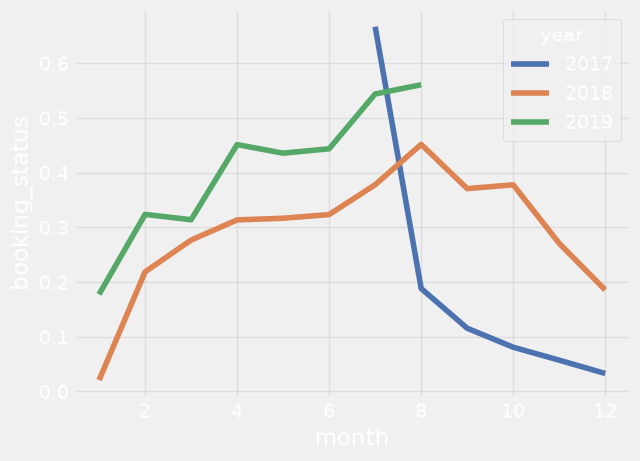

In [31]:
sns.lineplot(data = monthly, x = 'month', y = 'booking_status', hue = 'year', palette = 'deep');

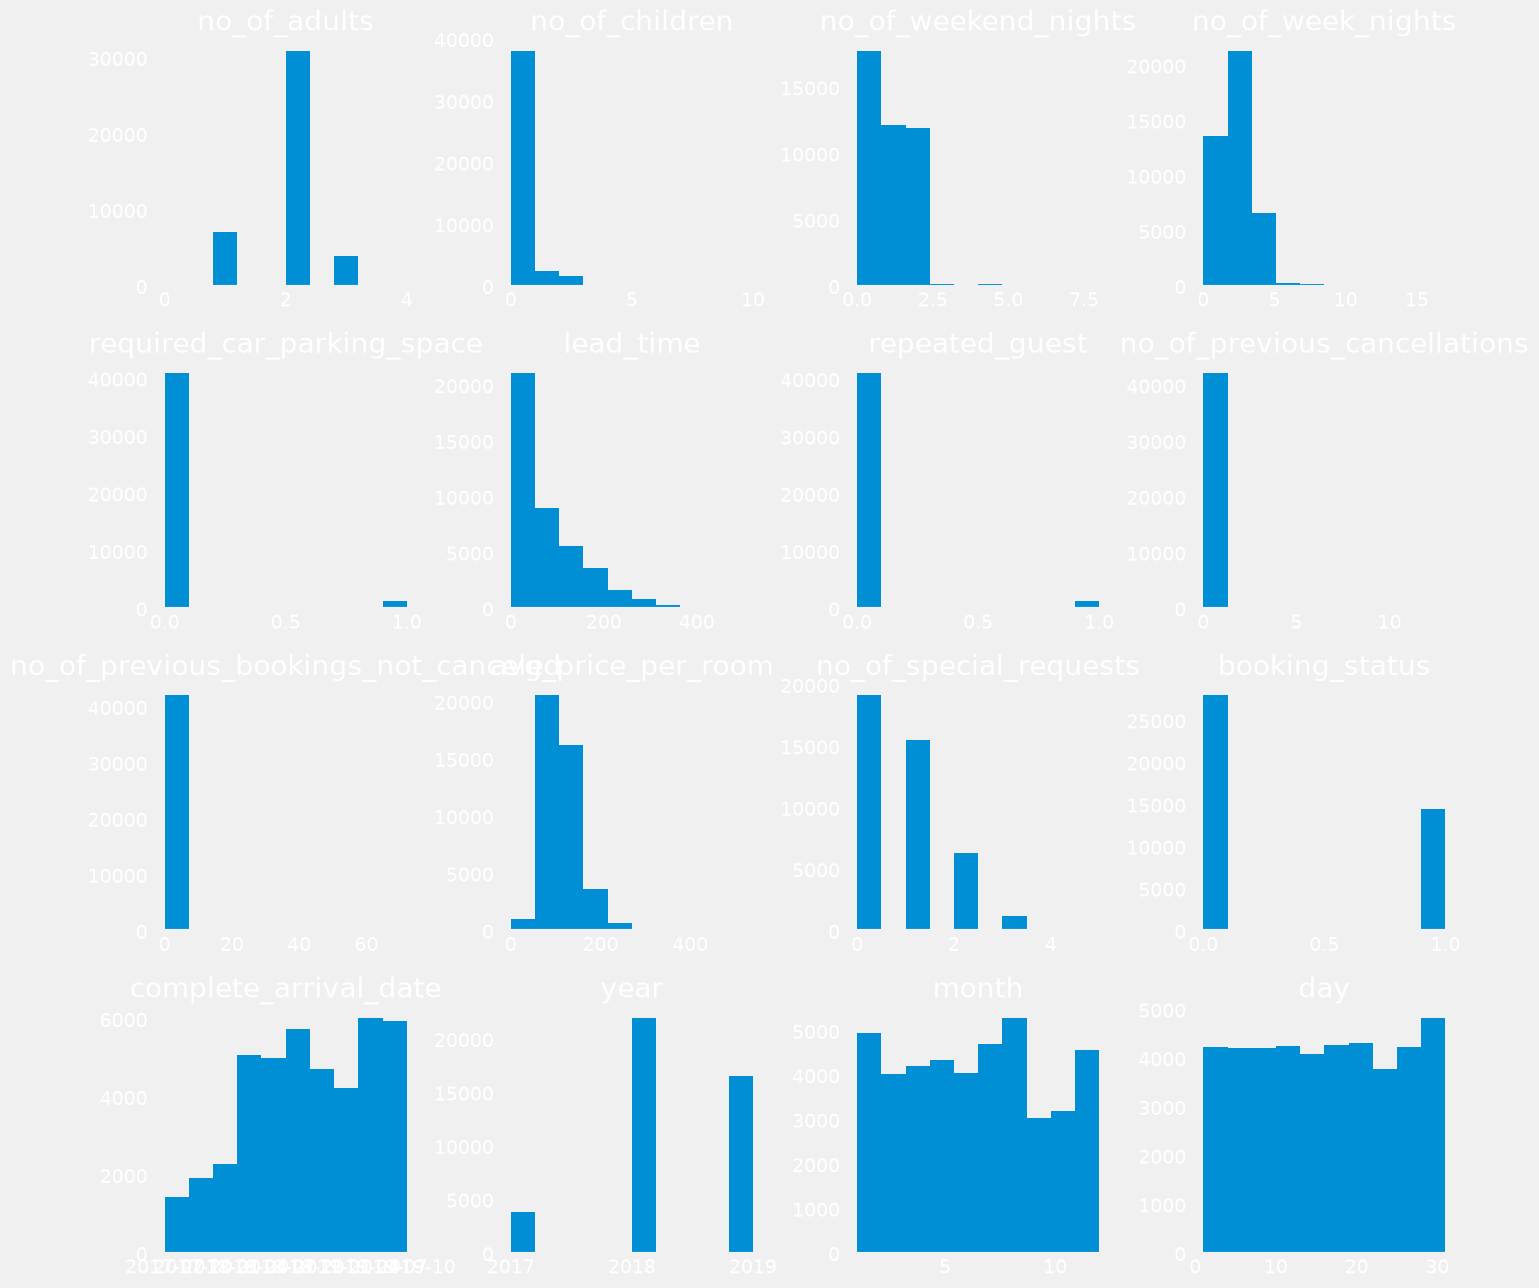

In [32]:
df.hist(figsize= (15,15), grid = False);

In [33]:
df.describe().round(2)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,complete_arrival_date,year,month,day
count,42541.00,42541.00,42541.00,42541.00,42541.00,42541.00,42541.00,42541.00,42541.00,42541.00,42541.00,42541.00,42541,42541.00,42541.00,42541.00
mean,1.92,0.14,0.90,2.32,0.03,77.35,0.03,0.03,0.22,112.39,0.77,0.34,2018-10-13 20:45:11.699301,2018.30,6.37,15.67
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2017-07-01 00:00:00,2017.00,1.00,1.00
25%,2.00,0.00,0.00,1.00,0.00,16.00,0.00,0.00,0.00,85.50,0.00,0.00,2018-05-12 00:00:00,2018.00,4.00,8.00
50%,2.00,0.00,1.00,2.00,0.00,53.00,0.00,0.00,0.00,107.00,1.00,0.00,2018-10-15 00:00:00,2018.00,6.00,16.00
75%,2.00,0.00,2.00,3.00,0.00,118.00,0.00,0.00,0.00,135.00,1.00,1.00,2019-04-14 00:00:00,2019.00,9.00,23.00
max,4.00,10.00,8.00,17.00,1.00,521.00,1.00,13.00,72.00,540.00,5.00,1.00,2019-08-31 00:00:00,2019.00,12.00,31.00
std,0.53,0.46,0.89,1.52,0.18,77.30,0.17,0.36,2.24,40.86,0.84,0.47,NaN,0.63,3.05,8.81


### Bivariate Analysis

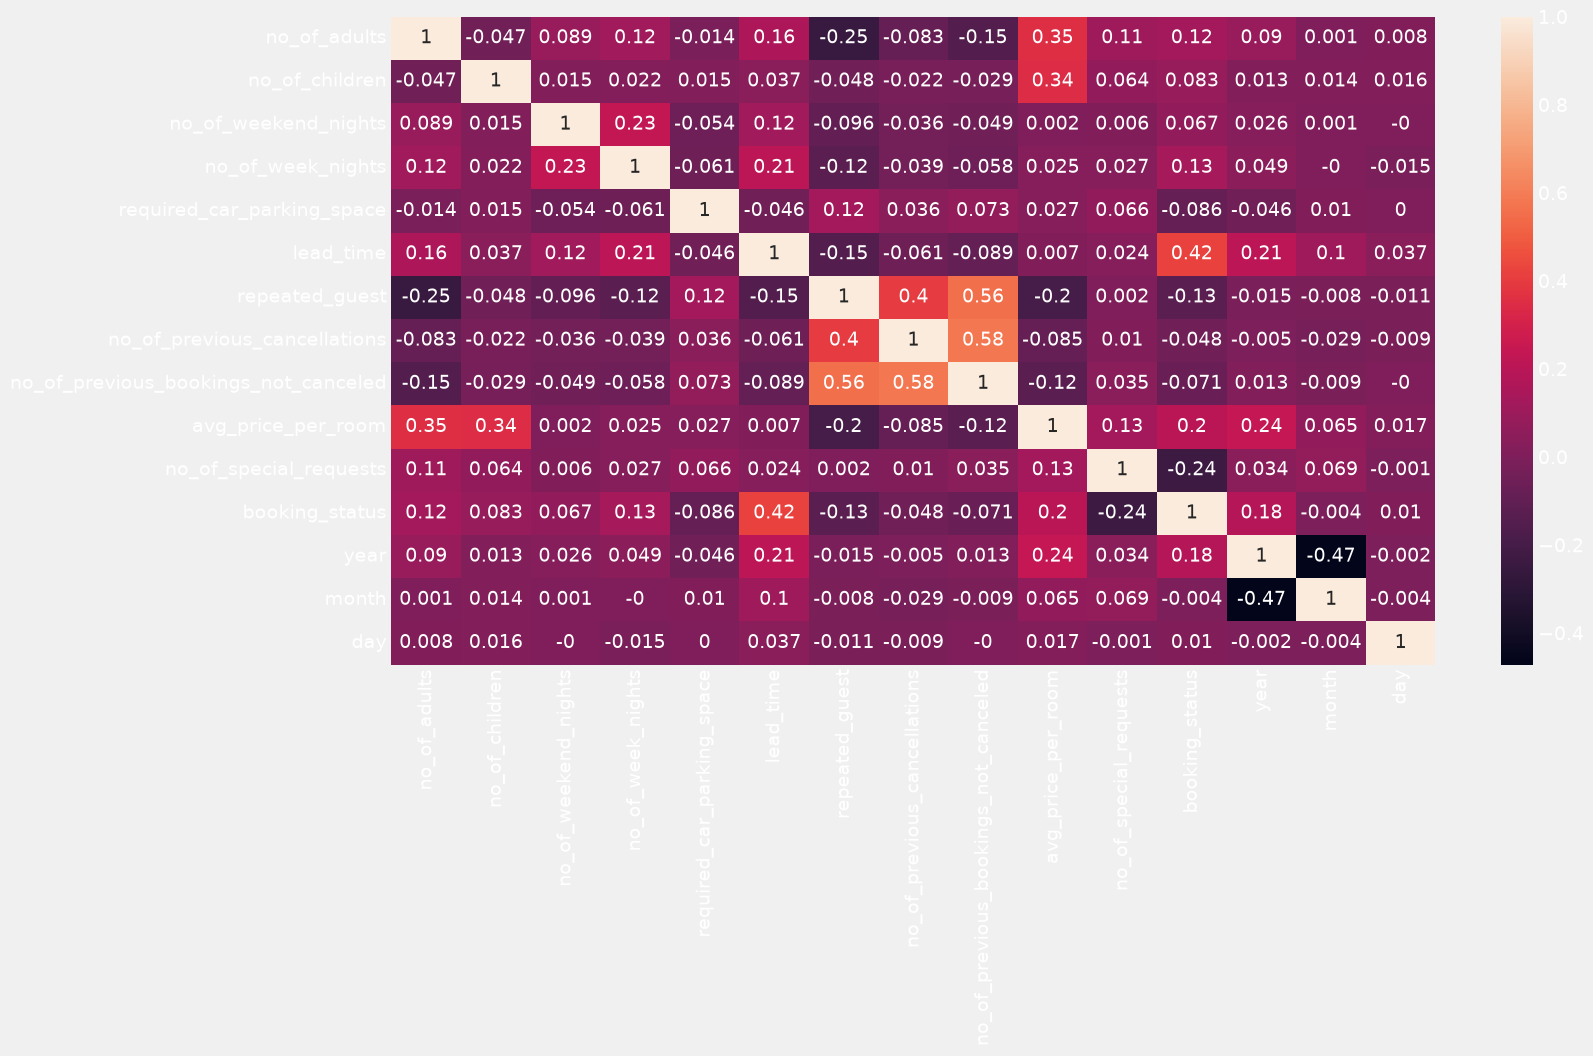

In [34]:
corr = df.corr(numeric_only = True).round(3)

plt.figure(figsize= (15,8))
sns.heatmap(corr, annot= True);

### Numerical

booking_status
0     54.02
1    122.56
Name: lead_time, dtype: float64

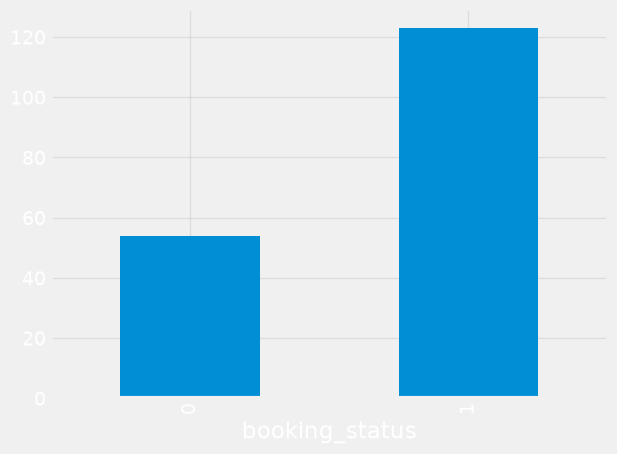

In [35]:
display(df.groupby('booking_status')['lead_time'].mean().round(2))

df.groupby('booking_status')['lead_time'].mean().round().plot(kind = "bar");

booking_status
0    106.50
1    123.81
Name: avg_price_per_room, dtype: float64

booking_status
0     99.45
1    117.00
Name: avg_price_per_room, dtype: float64

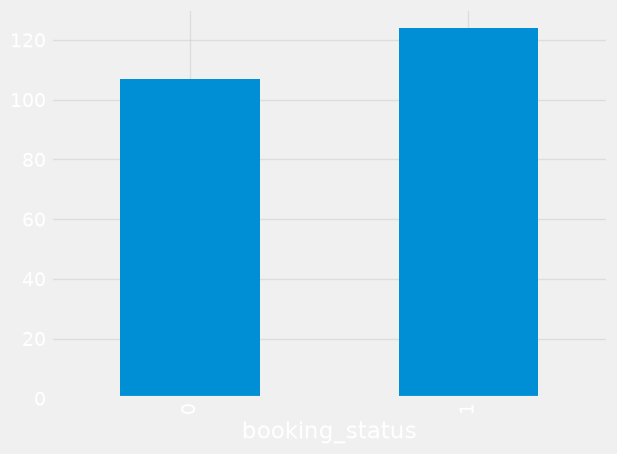

In [36]:
display(df.groupby('booking_status')['avg_price_per_room'].mean().round(2))
display(df.groupby('booking_status')['avg_price_per_room'].median().round(2))


df.groupby('booking_status')['avg_price_per_room'].mean().round().plot(kind = "bar");

### Categorical values and Booking Status

In [37]:
cat_list =  df.select_dtypes(['object']).columns.tolist()
cat_list

['type_of_meal_plan',
 'room_type_reserved',
 'market_segment_type',
 'month_name',
 'day_name']

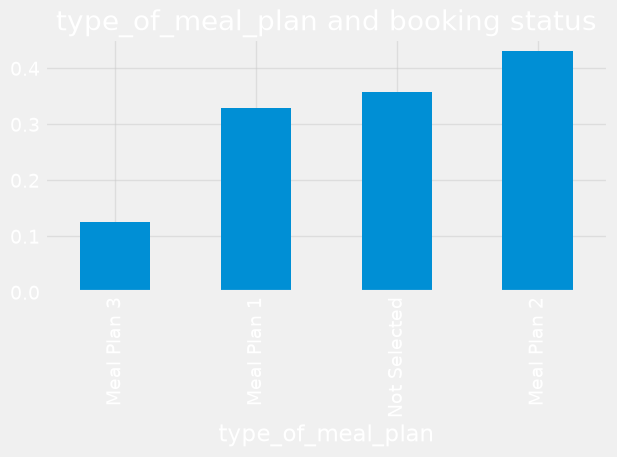

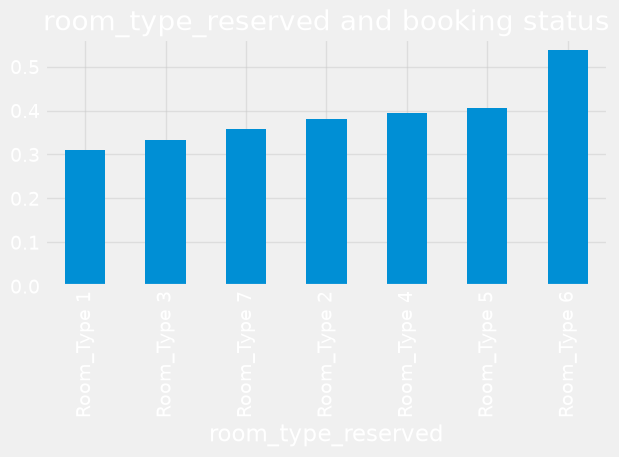

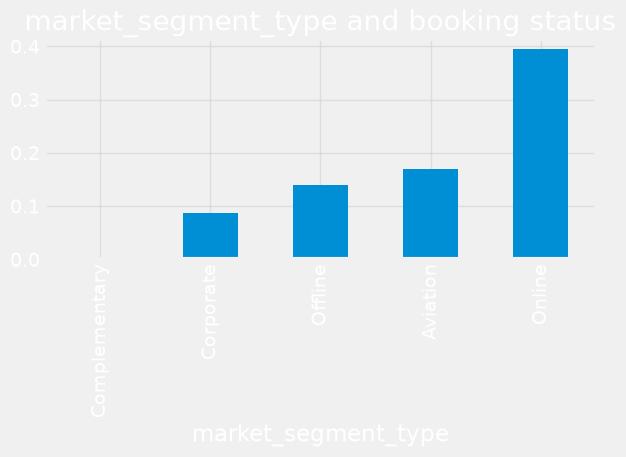

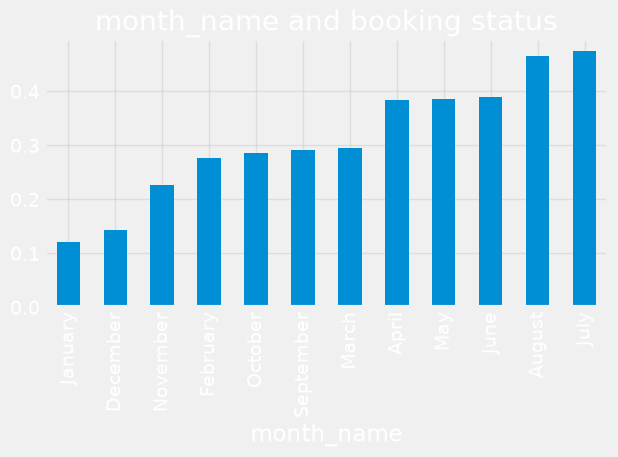

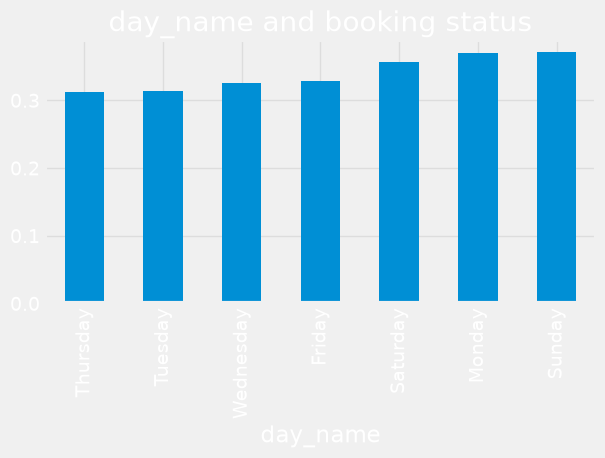

In [38]:
for cat in cat_list:
    df.groupby(cat)['booking_status'].mean().sort_values().plot(kind = 'bar', title = f'{cat} and booking status');
    plt.tight_layout()
    plt.show();

#### Crosstab View

In [39]:
for cat in cat_list:
    display(
        pd.crosstab(df[cat], df['booking_status'], normalize='columns') # one can use index for horizontal calculation
        .style
        .format('{:.0%}')
        .background_gradient(axis='index')
    )


booking_status,0,1
type_of_meal_plan,,
Meal Plan 1,76%,73%
Meal Plan 2,4%,6%
Meal Plan 3,0%,0%
Not Selected,20%,22%


booking_status,0,1
room_type_reserved,,
Room_Type 1,73%,64%
Room_Type 2,2%,2%
Room_Type 3,0%,0%
Room_Type 4,20%,25%
Room_Type 5,2%,3%
Room_Type 6,3%,6%
Room_Type 7,1%,1%


booking_status,0,1
market_segment_type,,
Aviation,1%,0%
Complementary,2%,0%
Corporate,6%,1%
Offline,18%,6%
Online,74%,93%


booking_status,0,1
month_name,,
April,9%,11%
August,10%,17%
December,7%,2%
February,7%,5%
January,7%,2%
July,9%,15%
June,9%,11%
March,10%,8%
May,10%,12%


booking_status,0,1
day_name,,
Friday,13%,12%
Monday,13%,15%
Saturday,14%,15%
Sunday,15%,17%
Thursday,13%,12%
Tuesday,15%,13%
Wednesday,16%,15%


#### Cross Tab Visualized

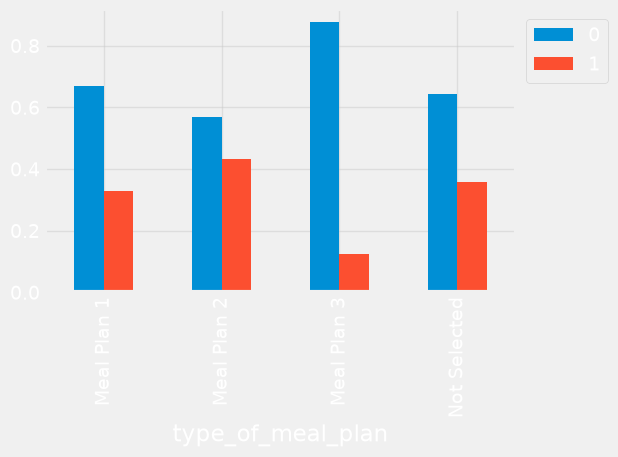

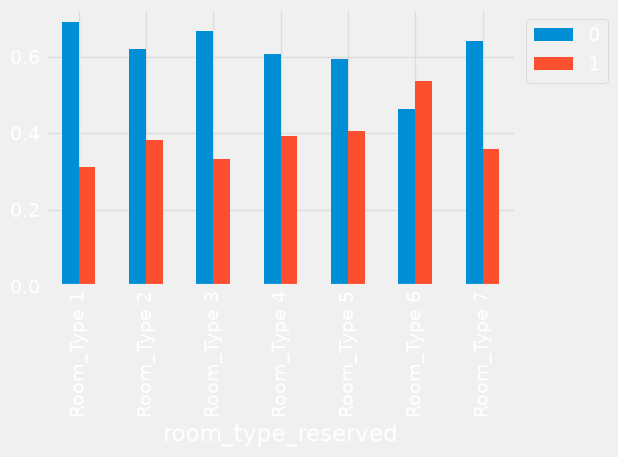

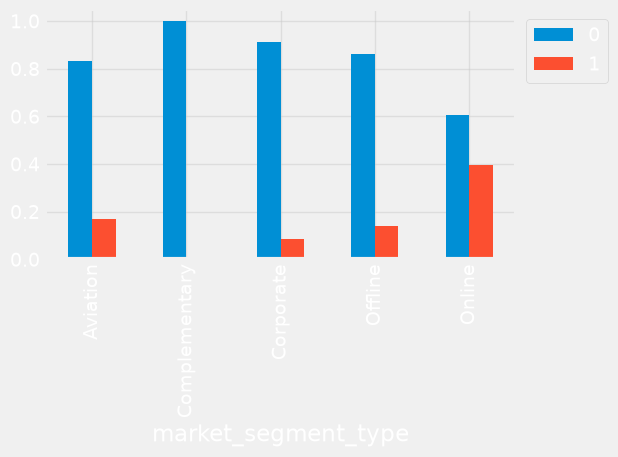

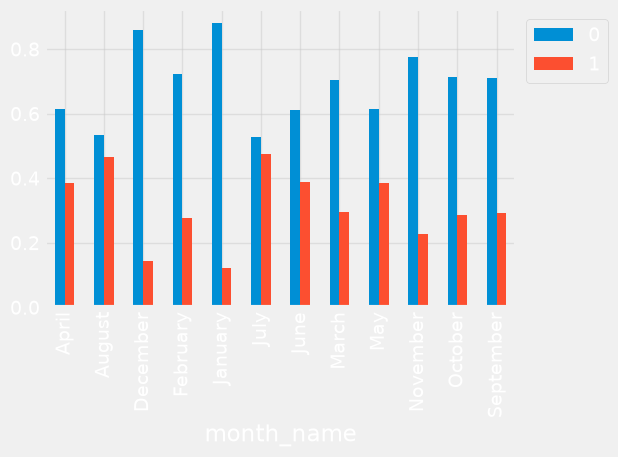

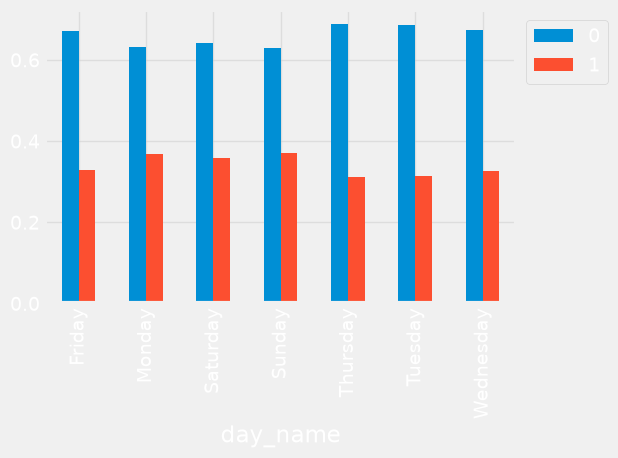

In [40]:
for cat in cat_list:
    ax = pd.crosstab(df[cat], df['booking_status'], normalize='index').plot(kind="bar")

    # Moving the legend and using 'loc' ensures it doesn't overlap the bars
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show();

##  <font color= darkred> Data Prep for Modeling </font>

**We will drop the columns not required for the analysis**

In [41]:
df.drop(columns = ['month_name', 'day_name', 'year', 'month', 'day', 'complete_arrival_date'], inplace = True)

### Train-Test Split

**This should always happen before the treatment of the Numerical and the Categorical data, otherwise data leakage happens, especially in the case of standardisation**

In [42]:
# data prep
from sklearn.model_selection import train_test_split

In [43]:
# splitting the data
X = df.drop(columns = 'booking_status')
y = df['booking_status']

In [44]:
# # doing train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [45]:
print("x_train: ", X_train.shape)
print("y_train: ", y_train.shape)


print("\n")

print("x_test: ", X_test.shape)
print("y_test: ", y_test.shape)

display(X_train.head())
display(y_train.head())


x_train:  (34032, 14)
y_train:  (34032,)


x_test:  (8509, 14)
y_test:  (8509,)


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
1097,2,0,1,3,Meal Plan 1,0,Room_Type 1,210,Offline,0,0,0,72.75,0
53296,2,0,0,1,Meal Plan 1,0,Room_Type 1,59,Offline,0,0,0,136.00,0
24022,2,0,1,2,Meal Plan 1,0,Room_Type 1,84,Online,0,0,0,127.80,0
6633,2,0,1,5,Not Selected,0,Room_Type 1,277,Online,0,0,0,82.17,2
38144,2,0,2,7,Meal Plan 2,0,Room_Type 4,17,Offline,0,0,0,108.20,0


1097     0
53296    0
24022    0
6633     0
38144    0
Name: booking_status, dtype: int64

### Pre-Processing

**We will do the whole operation using `sklearn` methods:**

*   `OneHotEncoder` for One hot encoding of the Categorical data
*   `StandardScaler` for the pre-processing of the numerical columns.

**We will make use of the `ColumnTransformer` to do the right mapping. It determines which columns get which pre-processin done.**

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [47]:
len(df.columns)

15

In [48]:
num_cols = ['no_of_adults', 'no_of_children', 'lead_time', 'no_of_weekend_nights', 'avg_price_per_room', 'no_of_week_nights', 'no_of_special_requests',
            'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled']

cat_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

print(len(num_cols) + len(cat_cols))

# mapping the pre-processing method
ct = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
        # ,("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        , ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output= False), cat_cols) # to be used only for Pandas output
    ],  remainder="passthrough"
)

# ensure output is pandas rather than numpy array
ct.set_output(transform="pandas")

12


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

⚠️**To have the Pandas output, you would need to have a dense output from the OneHotEncoder() rather than a sparse one, which is the default.Otherwise, it wont work**

💡**A sparse matrix stores only the non-zeros:memory roughly proportional to number of 1s efficient for many models, hence its the default of OHE**


⚠️**Should avoid Pandas output incase of high cardinality, many categorical values, tree ensemble method or neural network methods. Use it for debugging, Feature importance plots, learning**

💡**Can do the pandas output within pipeline as well**
  `pipe.set_output(transform="pandas")`



**Transformation on the train and test data**

In [49]:
# fit and transforming using Train
X_train_transformed = ct.fit_transform(X_train)

# transformin the test
X_test_transformed  = ct.transform(X_test)

In [50]:
ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

## <font color= darkred> Model building </font> 💥⚡

### Dummy classifier model using [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)

In [51]:
from sklearn.dummy import DummyClassifier

In [52]:
dummy = DummyClassifier()

In [53]:
dummy.fit(X_train_transformed, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.66,0.34]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](27,)","['num__no_of_adults','num__no_of_children','num__lead_time',..., 'cat__market_segment_type_Online','remainder__required_car_parking_space', 'remainder__repeated_guest']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,27
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [54]:
print(f"The accuracy score of the model for Train is {dummy.score(X_train_transformed, y_train):.1%}")
print(f"The accuracy score of the model for Test is {dummy.score(X_test_transformed, y_test):.1%}")

The accuracy score of the model for Train is 66.0%
The accuracy score of the model for Test is 66.0%


### Logistic Regression model using [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [55]:
from sklearn.linear_model import LogisticRegression

In [56]:
lr = LogisticRegression()

# fit the model
lr.fit(X_train_transformed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [57]:
print(f"The accuracy score of the model for Train is {lr.score(X_train_transformed, y_train):.1%}")
print(f"The accuracy score of the model for Test is {lr.score(X_test_transformed, y_test):.1%}")

The accuracy score of the model for Train is 79.2%
The accuracy score of the model for Test is 79.0%


### Decision Trees model using [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)


In [58]:
from sklearn.tree import DecisionTreeClassifier

In [59]:
dt = DecisionTreeClassifier(max_depth = None)

# fit the model
dt.fit(X_train_transformed, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [60]:
print(f"The accuracy score of the model for Train is {dt.score(X_train_transformed, y_train):.1%}")
print(f"The accuracy score of the model for Test is {dt.score(X_test_transformed, y_test):.1%}")

The accuracy score of the model for Train is 99.3%
The accuracy score of the model for Test is 77.3%


#### Properties of the tree

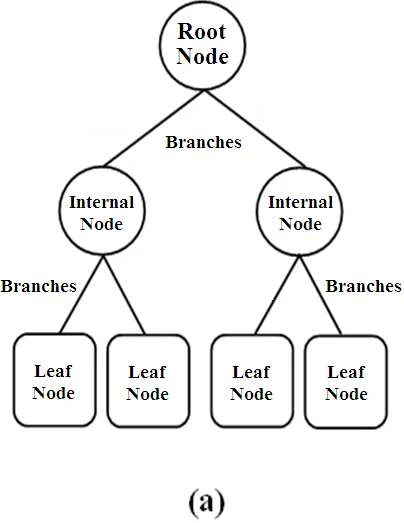

In [61]:
print(f"Max depth achieved: {dt.get_depth()}")
print(f"Total nodes (internal + leaves): {dt.tree_.node_count}")
print(f"Number of leaves: {dt.get_n_leaves()}")

print("\n--- Splitting constraints ---")
print(f"Max depth allowed: {dt.max_depth}")
print(f"Min samples split: {dt.min_samples_split}")
print(f"Min samples leaf: {dt.min_samples_leaf}")
print(f"Max features considered per split: {dt.max_features}")


Max depth achieved: 45
Total nodes (internal + leaves): 13331
Number of leaves: 6666

--- Splitting constraints ---
Max depth allowed: None
Min samples split: 2
Min samples leaf: 1
Max features considered per split: None


#### Significance of `max_depth`

In [62]:
max_depths = [1, 3, 5, 8, 10, 15, 20, 30, 40, 50]

dt_train_accuracies = []
dt_test_accuracies = []

for depth in max_depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train_transformed, y_train)

    dt_train_accuracies.append(dt.score(X_train_transformed, y_train))
    dt_test_accuracies.append(dt.score(X_test_transformed, y_test))

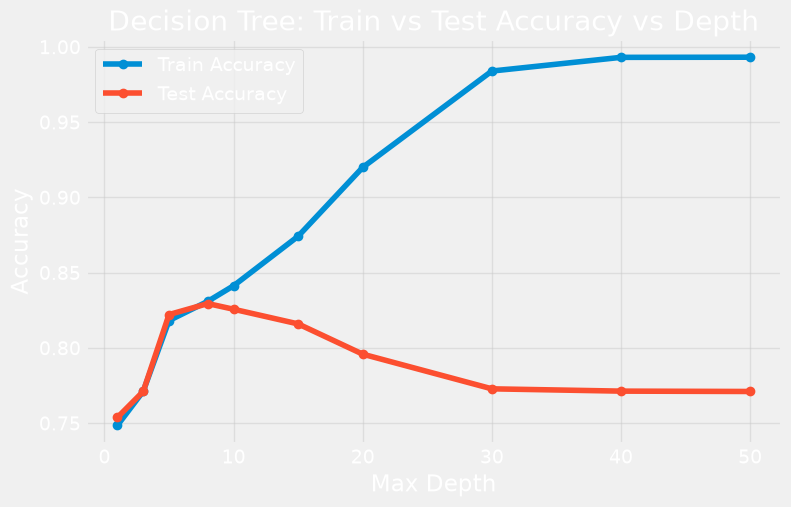

In [63]:
# generate a plot
plt.figure(figsize=(8, 5))
plt.plot(max_depths, dt_train_accuracies, marker='o', label='Train Accuracy')
plt.plot(max_depths, dt_test_accuracies, marker='o', label='Test Accuracy')

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Train vs Test Accuracy vs Depth")
plt.legend()
plt.grid(True)

plt.show()

#### **DT Feature Importance**

For a Decision Tree, feature importance is basically answering:

**Which features helped the tree make the best splits and reduce uncertainty the most?**

* Features that create the most useful splits get higher importance
* Feature Importance= ∑(Impurity Reduction × Number of Samples)
  * Impurity reduction is measured using Gini Impurity (sklearn default) or Entropy
* This is normalized, so all importance adds upto 1
* Each score shows the contribution of each feature in total impurity reduction achieved by the tree

In [64]:
# Create a list of feature names from the dataset
feature_names = list(X_train_transformed.columns)

# Get feature importances from the model
feature_importances = dt.feature_importances_

# table
dt_feature_imp_df = pd.DataFrame({"feature_names" : feature_names, "feature_importance": feature_importances}).sort_values(by = "feature_importance", ascending = False)

In [65]:
dt_feature_imp_df.head()#["feature_importance"].sum()

,feature_names,feature_importance
2,num__lead_time,0.398542
4,num__avg_price_per_room,0.225658
6,num__no_of_special_requests,0.101070
24,cat__market_segment_type_Online,0.079693
5,num__no_of_week_nights,0.067658


In [66]:
dt_feature_imp_df["feature_importance"].sum()

np.float64(1.0)

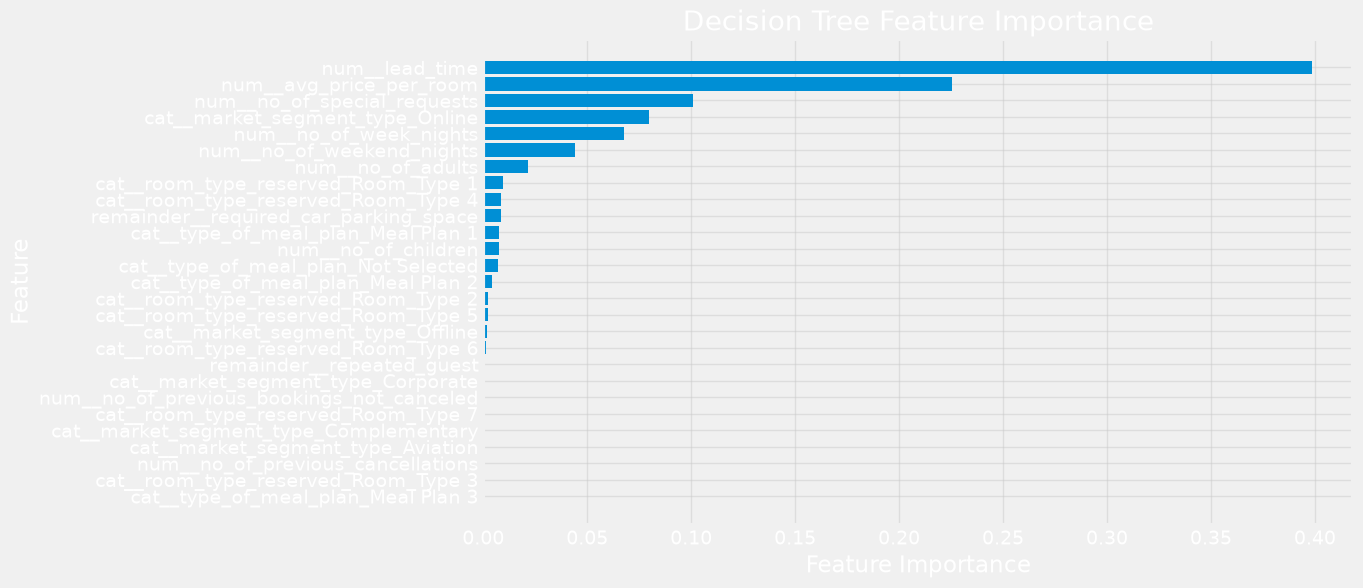

In [67]:
# plot the relationship
plt.figure(figsize=(10, 6))

plt.barh(dt_feature_imp_df["feature_names"],
    dt_feature_imp_df["feature_importance"]
)

# invert the chart
plt.gca().invert_yaxis()

# labels
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.show();

#### **Visualize a Decision Tree**

In [68]:
from sklearn import tree

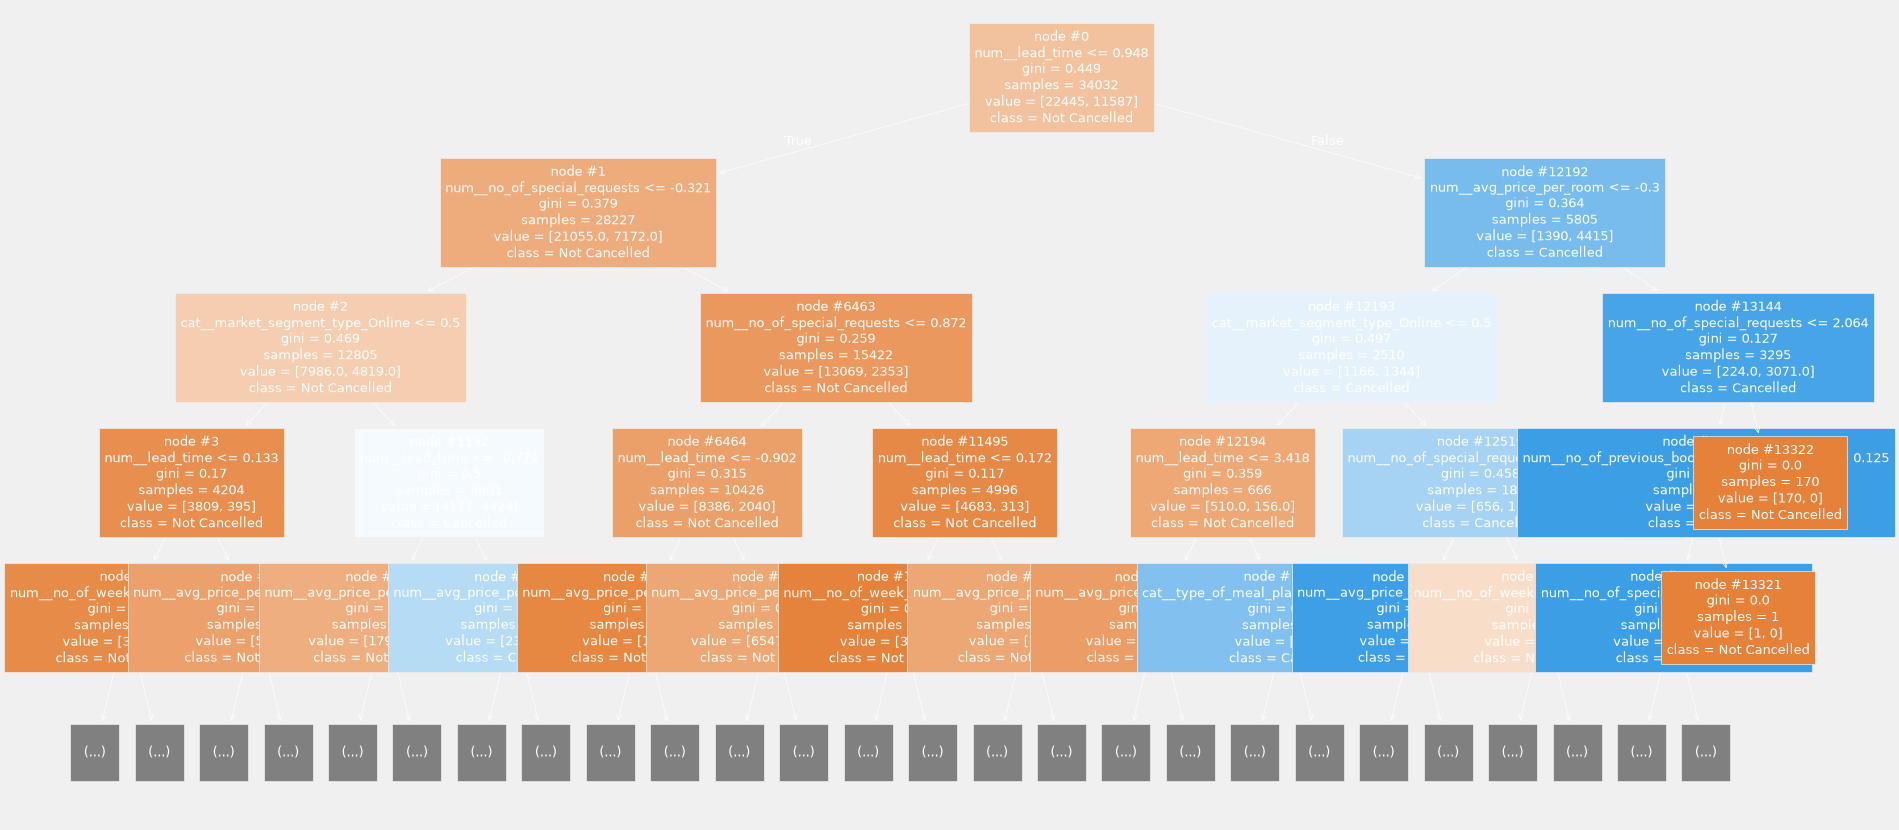

In [69]:
plt.figure(figsize=(20,10))

tree.plot_tree(dt
               , feature_names = feature_names # name of the features
               , max_depth = 4
               , filled= True # for color
               , fontsize= 9
               , node_ids = True # show the node number
               , class_names= ["Not Cancelled", "Cancelled"]) # Names of each of the target classes in ascending numerical order
# show the plot
plt.show()

#### Decision Tree Hyperparameters and Their Impact

| Hyperparameter | What it Controls | If Increased | If Decreased | Intuition |
|--------------|----------------|------------|-------------|-------------------|
| max_depth | Maximum tree depth | More complex tree, higher variance | Simpler tree, higher bias | How many questions the model is allowed to ask |
| min_samples_split | Minimum samples required to split a node | Fewer splits, smoother tree | More splits, risk of overfitting | Do I have enough data to justify a split |
| min_samples_leaf | Minimum samples required in a leaf | Leaves become more stable | Leaves can overfit noise | Prevents learning rules from very few samples |
| max_features | Number of features considered per split | More correlated splits | More randomness | Forces the tree to explore alternative splits |
| criterion | Split quality metric (gini or entropy) | No change in depth directly | No change in depth directly | Defines how purity is measured |
| min_impurity_decrease | Minimum impurity reduction required to split | Conservative splitting | Aggressive splitting | Split only if it is worth it |
| ccp_alpha | Cost complexity pruning strength | Smaller pruned tree | Larger complex tree | Penalizes unnecessary complexity |
| class_weight | Handling class imbalance | More focus on minority class | Bias toward majority class | Adjusts importance of different classes |
| random_state | Controls randomness | Reproducible structure | Different tree each run | Trees are naturally unstable |


### Gridsearch CV

**Parameter Grid**

In [73]:
# shorter version
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, 15, None]
 }


# Full blown version
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": [None, "balanced"]
}


param_grid

{'criterion': ['gini', 'entropy'],
 'max_depth': [3, 5, 7, 10, 15, None],
 'min_samples_split': [2, 5, 10, 20],
 'min_samples_leaf': [1, 2, 5, 10],
 'max_features': [None, 'sqrt', 'log2'],
 'class_weight': [None, 'balanced']}

In [75]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base model
dt = DecisionTreeClassifier(random_state=42)


# GridSearchCV
grid_search = GridSearchCV(
    estimator = dt,
    param_grid = param_grid,
    scoring="f1",          # use "accuracy" if classes are balanced
    cv=5,
    n_jobs=-1,
    verbose=0
)

# Fit
grid_search.fit(X_train_transformed, y_train)

# Best results
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

# Best model
best_dt = grid_search.best_estimator_

# Predict on test data
y_pred = best_dt.predict(X_test_transformed)

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Parameters:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}

Best CV Score:
0.7356832526446461

Test Accuracy:
0.8145493007403926

Confusion Matrix:
[[4712  904]
 [ 674 2219]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      5616
           1       0.71      0.77      0.74      2893

    accuracy                           0.81      8509
   macro avg       0.79      0.80      0.80      8509
weighted avg       0.82      0.81      0.82      8509



<div class="alert alert-block alert-success">

# 📚 Reference material

* [XGBoost versus Random Forest](https://www.qwak.com/post/xgboost-versus-random-forest)
* [How does the random forest model work? How is it different from bagging and boosting in ensemble models?](https://sebastianraschka.com/faq/docs/bagging-boosting-rf.html#:~:text=tl%3Bdr%3A%20Bagging%20and%20random,that%20underfit%20the%20training%20data)
* [Tabular Data: Deep Learning is Not All You Need](https://arxiv.org/abs/2106.03253)
    
</div>